In [1]:
# Enable GPU check
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies
!pip install opencv-contrib-python ultralytics

GPU: Tesla T4
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:00


In [12]:
import os, cv2, random, time
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

import torch
import torchvision
import torchvision.transforms as transforms

BASE = "/content/drive/MyDrive/Fruit_Image_Dataset"

TRAIN_PATH = f"{BASE}/train"
TEST_PATH = f"{BASE}/test"

classes = ["apple", "banana", "orange", "mixed"]

In [13]:
def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []
    for obj in root.findall("object"):
        label = obj.find("name").text
        bbox = obj.find("bndbox")

        x1 = int(bbox.find("xmin").text)
        y1 = int(bbox.find("ymin").text)
        x2 = int(bbox.find("xmax").text)
        y2 = int(bbox.find("ymax").text)

        cls_id = classes.index(label)
        boxes.append((cls_id, x1, y1, x2, y2))

    return boxes

In [14]:
def load_random_image(path):
    files = [f for f in os.listdir(path) if f.endswith(".jpg")]
    img_name = random.choice(files)

    img_path = os.path.join(path, img_name)
    xml_path = img_path.replace(".jpg", ".xml")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    boxes = parse_xml(xml_path)

    return img, boxes

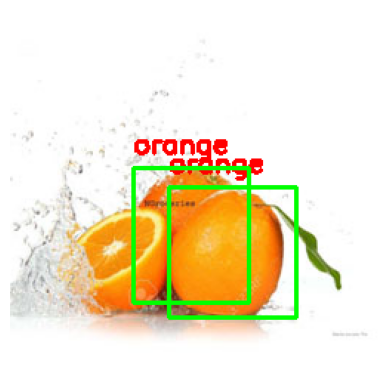

In [15]:
def show_boxes(img, boxes):
    temp = img.copy()

    for cls,x1,y1,x2,y2 in boxes:
        cv2.rectangle(temp,(x1,y1),(x2,y2),(0,255,0),2)
        cv2.putText(temp, classes[cls], (x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,0,0),2)

    plt.imshow(temp)
    plt.axis('off')
    plt.show()

image, gt_boxes = load_random_image(TRAIN_PATH)
show_boxes(image, gt_boxes)

# TASK 1

In [16]:
def compute_iou(a,b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[2],b[2]); y2=min(a[3],b[3])

    inter=max(0,x2-x1)*max(0,y2-y1)
    A=(a[2]-a[0])*(a[3]-a[1])
    B=(b[2]-b[0])*(b[3]-b[1])

    return inter/(A+B-inter) if (A+B-inter)>0 else 0

print(compute_iou([50,50,150,150],[60,60,140,140]))

0.64


# TASK 2

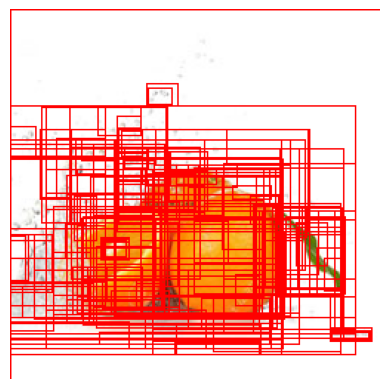

In [17]:
def selective_search(img):
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(img)
    ss.switchToSelectiveSearchFast()
    return ss.process()[:200]

def draw_ss(img, rects):
    temp = img.copy()
    for x,y,w,h in rects:
        cv2.rectangle(temp,(x,y),(x+w,y+h),(255,0,0),1)
    plt.imshow(temp); plt.axis('off'); plt.show()

rects = selective_search(image)
draw_ss(image, rects)

# TASK 3

In [18]:
model = torchvision.models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model = model.to(device).eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

start=time.time()

for (x,y,w,h) in rects[:100]:
    crop=image[y:y+h,x:x+w]
    if crop.size==0: continue

    inp=transform(crop).unsqueeze(0).to(device)

    with torch.no_grad():
        _=model(inp)

torch.cuda.synchronize()
print("R-CNN Time:", time.time()-start)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 48.7MB/s]


R-CNN Time: 1.303093433380127


# TASK 4

In [19]:
from torchvision.ops import roi_pool

inp=transform(image).unsqueeze(0).to(device)

start=time.time()

with torch.no_grad():
    feat=model(inp)

boxes=[[0,x,y,x+w,y+h] for (x,y,w,h) in rects[:100]]
boxes=torch.tensor(boxes,dtype=torch.float).to(device)

roi=roi_pool(feat, boxes, output_size=(7,7), spatial_scale=1/32)

torch.cuda.synchronize()
print("Fast R-CNN Time:", time.time()-start)

Fast R-CNN Time: 0.018585920333862305


# TASK 5

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 172MB/s]


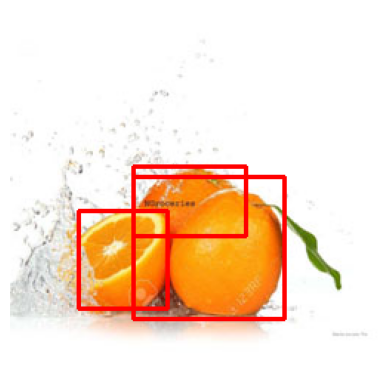

In [20]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model = model.to(device).eval()

img_tensor = transforms.ToTensor()(image).to(device)

with torch.no_grad():
    pred = model([img_tensor])[0]

pred = {k:v.cpu() for k,v in pred.items()}

keep = pred['scores'] > 0.8
boxes = pred['boxes'][keep]

temp=image.copy()
for b in boxes:
    x1,y1,x2,y2=map(int,b)
    cv2.rectangle(temp,(x1,y1),(x2,y2),(255,0,0),2)

plt.imshow(temp); plt.axis('off'); plt.show()

# TASK 6

In [21]:
def nms(boxes, scores, thresh=0.5):
    idxs=np.argsort(scores)[::-1]
    keep=[]

    while len(idxs)>0:
        i=idxs[0]
        keep.append(i)

        rem=[]
        for j in idxs[1:]:
            if compute_iou(boxes[i], boxes[j]) < thresh:
                rem.append(j)

        idxs=np.array(rem)

    return keep

# XML → YOLO

In [26]:
def convert_dataset(path):
    for file in os.listdir(path):
        if file.endswith(".jpg"):
            img_path = os.path.join(path, file)
            xml_path = img_path.replace(".jpg",".xml")

            img = cv2.imread(img_path)
            h,w,_ = img.shape

            boxes = parse_xml(xml_path)

            yolo=[]
            for cls,x1,y1,x2,y2 in boxes:
                xc=(x1+x2)/2/w
                yc=(y1+y2)/2/h
                bw=(x2-x1)/w
                bh=(y2-y1)/h
                yolo.append(f"{cls} {xc} {yc} {bw} {bh}")

            with open(xml_path.replace(".xml",".txt"),"w") as f:
                for line in yolo:
                    f.write(line+"\n")

convert_dataset(TRAIN_PATH)
convert_dataset(TEST_PATH)

# YAML FILE

In [27]:
yaml_content = f"""
train: {TRAIN_PATH}
val: {TEST_PATH}

nc: 4
names: ["apple","banana","orange","mixed"]
"""

with open(f"{BASE}/data.yaml","w") as f:
    f.write(yaml_content)

# YOLO TRAINING (GPU)

In [28]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=f"{BASE}/data.yaml",
    epochs=10,
    imgsz=640,
    device=0
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Fruit_Image_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7875e7789d00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

# INFERENCE + METRICS

In [29]:
model.predict(source=TEST_PATH, save=True)

metrics = model.val()
print(metrics)


image 1/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_77.jpg: 512x640 4 apples, 38.7ms
image 2/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_78.jpg: 640x640 1 apple, 21.1ms
image 3/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_79.jpg: 640x640 1 apple, 20.6ms
image 4/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_80.jpg: 544x640 1 apple, 66.2ms
image 5/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_81.jpg: 640x576 1 apple, 70.2ms
image 6/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_82.jpg: 640x576 1 apple, 7.2ms
image 7/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_83.jpg: 608x640 1 apple, 42.8ms
image 8/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_84.jpg: 448x640 5 apples, 63.2ms
image 9/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_85.jpg: 512x640 1 apple, 12.2ms
image 10/60 /content/drive/MyDrive/Fruit_Image_Dataset/test/apple_86.jpg: 448x640 3 apples, 11.4ms
image 11/60 /content/drive